# IMDB 影评二分类 - 使用早停与模型保存优化训练

本实验在基础二分类模型上，加入两种重要的训练优化机制：

## 1. EarlyStopping（早停）
当模型在验证集上的表现不再变好时，自动停止训练。
- 防止继续无意义训练
- 减少过拟合
- 节省训练时间

## 2. ModelCheckpoint（模型检查点）
在训练过程中，把"验证集表现最好"的模型参数保存下来。
- 即使后面训练变差，仍能拿到最好的模型
- 方便后续加载和部署

### 两者一起使用的意义
- `EarlyStopping` 负责"及时停下来"
- `ModelCheckpoint` 负责"把最好的模型保存下来"

这是实际深度学习项目中非常常见的搭配。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

## 1. 加载 IMDB 数据集

- 标签 0：负面评论
- 标签 1：正面评论

只保留训练集中最常见的前 10000 个单词。

In [2]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

print("训练集样本数：", len(train_data))
print("测试集样本数：", len(test_data))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
训练集样本数： 25000
测试集样本数： 25000


## 2. 数据向量化

将每条评论转换成长度为 10000 的向量：
- 某个单词出现过，对应位置记为 1
- 没有出现，则记为 0

**为什么要这样转？**

原始每条评论长度不一样，神经网络要求输入必须是固定长度，所以统一转成 10000 维的向量再喂进去。这种方式叫 **one-hot 向量化**，简单粗暴，但只知道"出现了哪些词"，不知道顺序。

**还有哪些替代方式？**

- **Padding（补齐）**：把每条评论补齐到同样长度（短的补0），保留了词序，但仍然是整数序列，需要配合 Embedding 层使用
- **Embedding 层**：把每个词映射成一个低维稠密向量（比如 128 维），模型自己学每个词的含义，是目前最主流的文本处理方式
- **LSTM / Transformer**：专门处理变长序列，不需要强行对齐长度，能捕捉词与词之间的顺序关系

当前用 one-hot 是因为配套的模型是简单 MLP，**够用就行**。后面学到 Embedding + LSTM/Transformer 就可以告别这种写法了。

In [3]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [4]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (25000, 10000)
x_test shape: (25000, 10000)


## 3. 划分验证集

- 前 10000 条作为验证集
- 后面的样本作为真正的训练集

In [5]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print("验证集形状：", x_val.shape, y_val.shape)
print("训练集形状：", partial_x_train.shape, partial_y_train.shape)

验证集形状： (10000, 10000) (10000,)
训练集形状： (15000, 10000) (15000,)


## 4. 构建二分类模型

- 第一隐藏层：16个神经元，ReLU
- 第二隐藏层：16个神经元，ReLU
- 输出层：1个神经元，Sigmoid

In [6]:
model = models.Sequential()
model.add(layers.Dense(16, activation="relu", input_shape=(10000,)))
model.add(layers.Dense(16, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## 5. 定义 EarlyStopping 和 ModelCheckpoint

### EarlyStopping 参数说明
- `monitor='val_loss'`：监控验证损失
- `patience=2`：连续2轮没有改善则停止
- `restore_best_weights=True`：自动恢复最佳参数

### ModelCheckpoint 参数说明
- `filepath='best_imdb_model.keras'`：保存最佳模型的文件名
- `monitor='val_loss'`：监控验证损失
- `save_best_only=True`：只保存验证集表现最好的模型
- `mode='min'`：损失越小越好


**原理（大白话）**

Keras 的 `fit()` 每训完一轮，就会把当前指标打包成字典广播给所有 callback：
```python
logs = {"loss": 0.31, "accuracy": 0.87, "val_loss": 0.40, "val_accuracy": 0.86}
```
- 训练集指标直接用指标名（`loss`、`accuracy`）
- 验证集指标自动加前缀（`val_loss`、`val_accuracy`）

callback 收到 `logs` 后，用 `monitor` 指定的键去里面取值来判断要不要停训/存档。

**参数名从哪来的？**

`monitor`、`patience`、`restore_best_weights` 这些键名不是你自己取的，是 **Keras 源码里写死的构造函数参数**，你传的名字必须和源码一致。查官方文档就能看到所有可用参数名。

总结：**参数名是 Keras 源码定的，`logs` 的键名是 `fit()` 运行时动态生成的**，两套命名来源不同，但 `monitor` 的值要跟 `logs` 的键对上，Keras 才能找到对应指标去比较。

In [7]:
# 早停机制：当验证损失不再下降时自动停止
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# 模型保存：保存验证集表现最好的模型
checkpoint = ModelCheckpoint(
    filepath="best_imdb_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

## 6. 开始训练模型

- 最大训练 20 轮
- 如果验证损失不再改善，`EarlyStopping` 会让训练提前结束
- 每当验证损失刷新最好成绩时，`ModelCheckpoint` 自动保存当前最佳模型

In [8]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6875 - loss: 0.6135
Epoch 1: val_loss improved from None to 0.43171, saving model to best_imdb_model.keras

Epoch 1: finished saving model to best_imdb_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7775 - loss: 0.5399 - val_accuracy: 0.8382 - val_loss: 0.4317
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8861 - loss: 0.3632
Epoch 2: val_loss improved from 0.43171 to 0.32092, saving model to best_imdb_model.keras

Epoch 2: finished saving model to best_imdb_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8929 - loss: 0.3381 - val_accuracy: 0.8819 - val_loss: 0.3209
Epoch 3/20
27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9137 - loss: 0.2636
Epoch 3: val_loss improved from 0.32092 to 0.29004, saving model to best_imdb_model.keras

Epoch 3: finished saving model to best_imdb_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9166 - loss: 0.2535 -

## 7. 查看训练历史记录

In [9]:
history_dict = history.history
print(history_dict.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


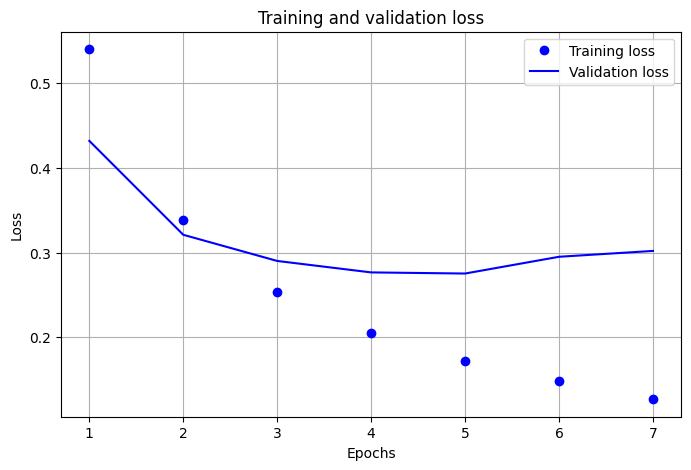

In [10]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

### 损失曲线解读

- 训练损失不断下降
- 验证损失先下降后可能上升（过拟合）
- 早停机制会在验证损失不再改善时自动停止

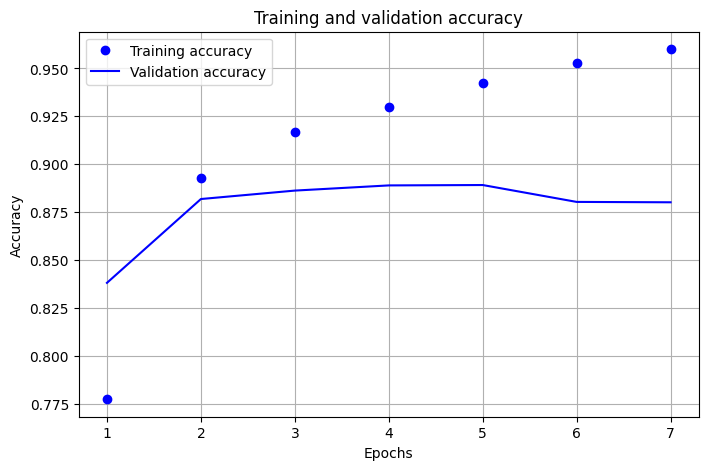

In [11]:
acc_values = history_dict["accuracy"]
val_acc_values = history_dict["val_accuracy"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc_values, "bo", label="Training accuracy")
plt.plot(epochs, val_acc_values, "b", label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 8. 加载训练过程中保存的最佳模型

即使训练结束、Notebook关闭、程序重启，也可以重新使用保存的最佳模型。

In [12]:
best_model = load_model("best_imdb_model.keras")
print("最佳模型加载成功。")
best_model.summary()

最佳模型加载成功。


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,612 (1.22 MB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 160,307 (626.20 KB)

## 9. 在测试集上评估最佳模型

In [13]:
results = best_model.evaluate(x_test, y_test)
print("测试损失：", results[0])
print("测试准确率：", results[1])

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8824 - loss: 0.2917
测试损失： 0.2916780412197113
测试准确率： 0.8824399709701538


## 10. 使用最佳模型进行预测

sigmoid 输出 0~1 之间的概率值：
- 接近 1：正面评论
- 接近 0：负面评论

In [14]:
predictions = best_model.predict(x_test)

print("前10条预测概率：")
print(predictions[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
前10条预测概率：
[[0.23510148]
 [0.998835  ]
 [0.90791065]
 [0.7147629 ]
 [0.8905291 ]
 [0.81889236]
 [0.9982274 ]
 [0.01395612]
 [0.9375502 ]
 [0.97835547]]


In [15]:
predicted_labels = (predictions >= 0.5).astype("int32")
print("前20条预测类别：")
print(predicted_labels[:20].reshape(-1))

前20条预测类别：
[0 1 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 1 0 0]


## 11. 实验总结

本实验在 IMDB 影评二分类任务中，同时加入了：

| 机制 | 作用 |
|------|------|
| `EarlyStopping` | 防止过拟合、节省训练时间、自动恢复最佳权重 |
| `ModelCheckpoint` | 保存验证集表现最好的模型、方便后续加载部署 |

### 主要流程
1. 加载 IMDB 数据集
2. 将文本整数序列向量化
3. 划分训练集和验证集
4. 构建二分类神经网络
5. 使用 `EarlyStopping` 自动停止训练
6. 使用 `ModelCheckpoint` 保存验证集最佳模型
7. 重新加载最佳模型
8. 在测试集上评估最佳模型效果

### 实际项目中的意义
在实际深度学习训练中，这两个回调函数是常见的搭配：
- 一个负责"及时停"
- 一个负责"保存最好结果"

这样训练过程更稳、更规范。